# Volume Objective


In this example, we compute the maximal (resp. minimal) volume ellipsoids
and polynomial sublevel sets contained in (resp. containing) the square with
vertices $(\pm 1, \pm 1)$. We start by defining the square with
[Polyhedra](https://github.com/JuliaPolyhedra/Polyhedra.jl).

In [1]:
using Polyhedra
h = HalfSpace([1, 0], 1.0) ∩ HalfSpace([-1, 0], 1) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
p = polyhedron(h)

Polyhedron DefaultPolyhedron{Float64, Polyhedra.Intersection{Float64, Vector{Float64}, Int64}, Polyhedra.Hull{Float64, Vector{Float64}, Int64}}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([1.0, 0.0], 1.0)
 HalfSpace([-1.0, 0.0], 1.0)
 HalfSpace([0.0, 1.0], 1.0)
 HalfSpace([0.0, -1.0], 1.0)

We need to pick an SDP solver, see
[here](https://jump.dev/JuMP.jl/stable/installation/#Supported-solvers)
for a list of available ones.

In [2]:
using SetProg
import Hypatia
sdp_solver = optimizer_with_attributes(Hypatia.Optimizer, MOI.Silent() => true)

MathOptInterface.OptimizerWithAttributes(Hypatia.Optimizer, Pair{MathOptInterface.AbstractOptimizerAttribute, Any}[MathOptInterface.Silent() => true])

## John ellipsoid

The maximal volume ellipsoid contained in a convex body is called its John
ellipsoid. The John ellipsoid for our square can be computed as follows.

In [3]:
model = Model(sdp_solver)
@variable(model, john, Ellipsoid(symmetric=true, dimension=2))
@constraint(model, john ⊆ p)
@objective(model, Max, nth_root(volume(john)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
SetProg.Sets.print_support_function(value(john))

solve_time(model) = 0.0015819072723388672
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.9999999663952056
h(S, x) = x[2]^2 + x[1]^2


### Which cone does the solver receive ?

The objective `nth_root(volume(john))` is reformulated by SetProg into a
new variable `t` constrained by `[t; vec(Q)] in MOI.RootDetConeTriangle(2)`
where `Q` is the matrix of the ellipsoid. We can see these reformulated
constraints with `list_of_constraint_types`:

In [4]:
list_of_constraint_types(model)

3-element Vector{Tuple{Type, Type}}:
 (AffExpr, MathOptInterface.LessThan{Float64})
 (Vector{VariableRef}, MathOptInterface.RootDetConeTriangle)
 (Vector{VariableRef}, SumOfSquares.PositiveSemidefinite2x2ConeTriangle)

The solver may not support every one of these constraints natively. In that
case, JuMP transforms them using *bridges*. For instance, a solver only
supporting positive semidefinite constraints would receive the
`RootDetConeTriangle` reformulated with a `GeometricMeanCone` and a
`PositiveSemidefiniteConeTriangle`, so with additional variables and
constraints. Hypatia supports the root-determinant cone natively, and we can
check that with `print_active_bridges`. It shows, for each constraint
type of the model, which bridges are used and which constraints the solver
receives in the end.

In [5]:
print_active_bridges(model)

 * Supported objective: MOI.VariableIndex
 * Unsupported constraint: MOI.ScalarAffineFunction{Float64}-in-MOI.LessThan{Float64}
 |  bridged by:
 |   MOIB.Constraint.LessToGreaterBridge{Float64, MOI.ScalarAffineFunction{Float64}, MOI.ScalarAffineFunction{Float64}}
 |  may introduce:
 |   * Unsupported constraint: MOI.ScalarAffineFunction{Float64}-in-MOI.GreaterThan{Float64}
 |   |  bridged by:
 |   |   MOIB.Constraint.VectorizeBridge{Float64, MOI.VectorAffineFunction{Float64}, MOI.Nonnegatives, MOI.ScalarAffineFunction{Float64}}
 |   |  may introduce:
 |   |   * Supported constraint: MOI.VectorAffineFunction{Float64}-in-MOI.Nonnegatives
 * Unsupported constraint: MOI.VectorOfVariables-in-MOI.RootDetConeTriangle
 |  bridged by:
 |   MOIB.Constraint.SetDotScalingBridge{Float64, MOI.RootDetConeTriangle, MOI.VectorAffineFunction{Float64}, MOI.VectorOfVariables}
 |  may introduce:
 |   * Supported constraint: MOI.VectorAffineFunction{Float64}-in-MOI.Scaled{MOI.RootDetConeTriangle}
 * Unsuppo

To only look at the root-determinant cone, we give its function and set type:

In [6]:
print_active_bridges(model, Vector{VariableRef}, MOI.RootDetConeTriangle)

 * Unsupported constraint: MOI.VectorOfVariables-in-MOI.RootDetConeTriangle
 |  bridged by:
 |   MOIB.Constraint.SetDotScalingBridge{Float64, MOI.RootDetConeTriangle, MOI.VectorAffineFunction{Float64}, MOI.VectorOfVariables}
 |  may introduce:
 |   * Supported constraint: MOI.VectorAffineFunction{Float64}-in-MOI.Scaled{MOI.RootDetConeTriangle}


The only bridge is `SetDotScalingBridge`. It only rescales the off-diagonal
entries into the `MOI.Scaled{MOI.RootDetConeTriangle}` set, which is the
form in which Hypatia supports the cone natively. There is no
`GeometricMeanCone` or `PositiveSemidefiniteConeTriangle`.

### Log-determinant objective

Instead of the `n`th root of the determinant, we can also maximize its
logarithm with `log(volume(john))`. The optimal ellipsoid is the same, but
the objective value is now `log(det(Q)) = log(1) = 0` instead of
`det(Q)^(1/2) = 1`.

In [7]:
model = Model(sdp_solver)
@variable(model, john_log, Ellipsoid(symmetric=true, dimension=2))
@constraint(model, john_log ⊆ p)
@objective(model, Max, log(volume(john_log)))
optimize!(model)
@show termination_status(model)
@show objective_value(model)
SetProg.Sets.print_support_function(value(john_log))

termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = -1.9304391854351855e-8
h(S, x) = x[2]^2 + x[1]^2


The objective is now reformulated into `[t; 1; vec(Q)] in MOI.LogDetConeTriangle(2)`
which means `t ≤ log(det(Q))`. As the constant `1` is part of the function,
it is a `Vector{AffExpr}` instead of a `Vector{VariableRef}`.
Hypatia also supports this cone natively:

In [8]:
print_active_bridges(model, Vector{AffExpr}, MOI.LogDetConeTriangle)

 * Unsupported constraint: MOI.VectorAffineFunction{Float64}-in-MOI.LogDetConeTriangle
 |  bridged by:
 |   MOIB.Constraint.SetDotScalingBridge{Float64, MOI.LogDetConeTriangle, MOI.VectorAffineFunction{Float64}, MOI.VectorAffineFunction{Float64}}
 |  may introduce:
 |   * Supported constraint: MOI.VectorAffineFunction{Float64}-in-MOI.Scaled{MOI.LogDetConeTriangle}


## Löwner ellipsoid

The minimal volume ellipsoid containing a convex body is called its Löwner
ellipsoid. The Löwner ellipsoid for our square can be computed as follows.

In [9]:
model = Model(sdp_solver)
@variable(model, löwner, Ellipsoid(symmetric=true, dimension=2))
@constraint(model, p ⊆ löwner)
@objective(model, Min, nth_root(volume(löwner)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
löwner_value = value(löwner)

solve_time(model) = 0.0019750595092773438
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.4999999898354531


SetProg.Sets.Ellipsoid{Float64}([0.49999998368834947 6.323710909172985e-18; 6.323710909172985e-18 0.4999999836865327])

We can visualize the Löwner and John ellipsoids as follows.

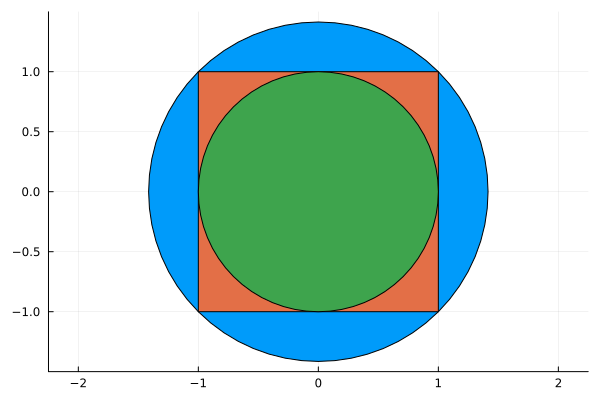

In [10]:
using Plots
plot(ratio=:equal)
plot!(löwner_value)
plot!(p)
plot!(value(john))

## Higher degree polynomials

Ellipsoids are the sublevel sets of positive definite *quadratic* forms. To
allow for more sophisticated shapes, we instead look for sublevel sets of
*quartic* forms. For this, we simply replace `Ellipsoid(dimension=2)` by
`PolySet(degree=4, dimension=2)`. Note that the quantities optimized are
not exactly the volume anymore but provide a reasonable heuristic.

### Maximal volume quartic sublevel set contained in the square

In [11]:
model = Model(sdp_solver)
@variable(model, quartic_inner, PolySet(degree=4, symmetric=true, convex=true))
@constraint(model, quartic_inner ⊆ p)
@objective(model, Max, nth_root(volume(quartic_inner)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
quartic_inner_value = value(quartic_inner)

solve_time(model) = 0.002113819122314453
termination_status(model) = OPTIMAL
objective_value(model) = 6.44741947110107


SetProg.Sets.Polar{Float64, SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64

### Minimal volume quartic sublevel set containing the square

In [12]:
model = Model(sdp_solver)
@variable(model, quartic_outer, PolySet(symmetric=true, degree=4, convex=true))
@constraint(model, p ⊆ quartic_outer)
@objective(model, Min, nth_root(volume(quartic_outer)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
quartic_outer_value = value(quartic_outer)

solve_time(model) = 0.0015511512756347656
termination_status(model) = OPTIMAL
objective_value(model) = 1.6118548911738118


SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64}}}, Float64}(4, GramMatrix 

We can visualize the quartic sublevel sets as follows.

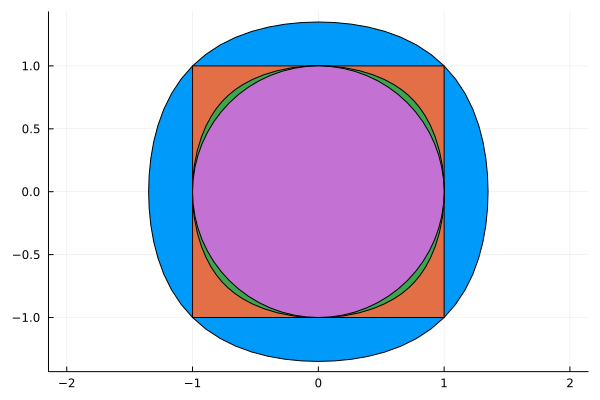

In [13]:
plot(ratio=:equal)
plot!(quartic_outer_value)
plot!(p)
plot!(quartic_inner_value)
plot!(value(john))

### Inner sublevel sets of increasing degree

We can also explore how the inner sublevel set tightens as the degree grows,
using the `L1_heuristic` as a tractable volume proxy.

solve_time(model) = 0.0010600090026855469
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.6666665860813485
solve_time(model) = 0.0012359619140625
termination_status(model) = OPTIMAL
objective_value(model) = 0.3999999551364992
solve_time(model) = 0.002096891403198242
termination_status(model) = OPTIMAL
objective_value(model) = 0.2857142199955906
solve_time(model) = 0.003133058547973633
termination_status(model) = OPTIMAL
objective_value(model) = 0.22628881898089873
solve_time(model) = 0.005813121795654297
termination_status(model) = OPTIMAL
objective_value(model) = 0.1842521245670916


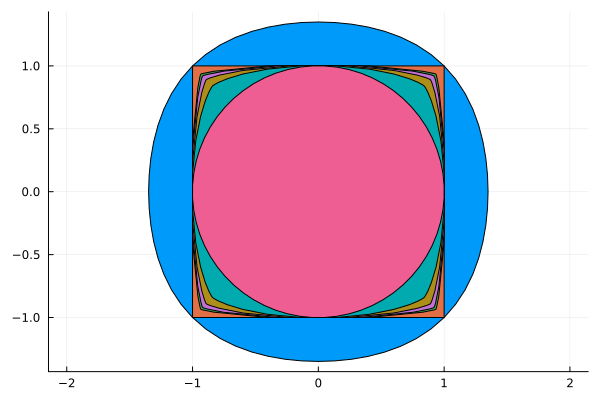

In [14]:
function inner_L1(d)
    model = Model(sdp_solver)
    @variable(model, S, PolySet(symmetric=true, degree=d, convex=true))
    @constraint(model, S ⊆ p)
    @objective(model, Max, L1_heuristic(volume(S), [1.0, 1.0]))
    optimize!(model)
    @show solve_time(model)
    @show termination_status(model)
    @show objective_value(model)
    return value(S)
end

S2 = inner_L1(2)
S4 = inner_L1(4)
S6 = inner_L1(6)
S8 = inner_L1(8)
S10 = inner_L1(10)

plot(ratio=:equal)
plot!(quartic_outer_value)
plot!(p)
plot!(S10)
plot!(S8)
plot!(S6)
plot!(S4)
plot!(S2)

## Non-homogeneous case

For non-symmetric bodies, the John/Löwner ellipsoids are not centered at the
origin. We need to provide a `point` as a hint of an interior point. We
illustrate on a horizontally-shifted square.

solve_time(model) = 0.0016720294952392578
termination_status(model) = OPTIMAL
objective_value(model) = 0.3043768286913625


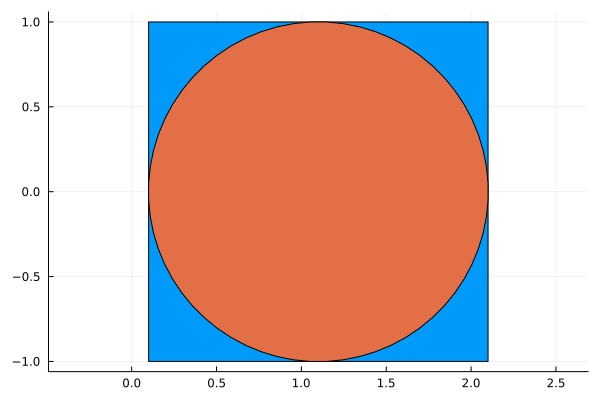

In [15]:
shift = 1.1
h_shift = HalfSpace([1, 0], 1.0 + shift) ∩ HalfSpace([-1, 0], 1.0 - shift) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
p_shift = polyhedron(h_shift)

model = Model(sdp_solver)
@variable(model, john_shift, Ellipsoid(point=SetProg.InteriorPoint([shift, 0.0])))
@constraint(model, john_shift ⊆ p_shift)
@objective(model, Max, nth_root(volume(john_shift)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)

plot(ratio=:equal)
plot!(p_shift)
plot!(value(john_shift))

Likewise for the quartic sublevel set.

solve_time(model) = 0.0010600090026855469
termination_status(model) = OPTIMAL
objective_value(model) = 0.8763129605060004


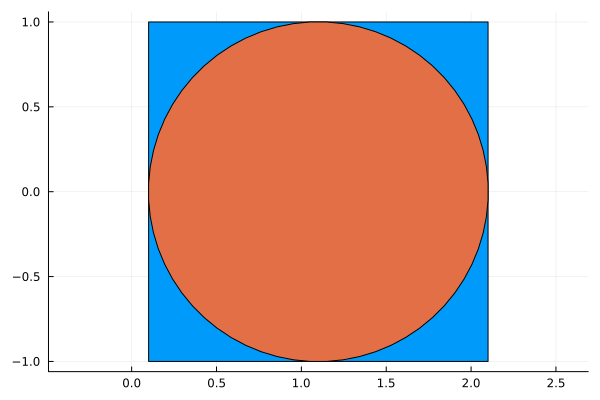

In [16]:
model = Model(sdp_solver)
@variable(model, quartic_shift, PolySet(convex=true, degree=2, point=SetProg.InteriorPoint([shift, 0.0])))
@constraint(model, quartic_shift ⊆ p_shift)
@objective(model, Max, L1_heuristic(volume(quartic_shift), [1.0, 1.0]))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)

plot(ratio=:equal)
plot!(p_shift)
plot!(value(quartic_shift))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*